In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
latent_dim = 128
batch_size = 128
num_epochs_ae = 4
num_epochs_cls = 4
learning_rate = 1e-3
# Early stopping parameters
patience = 3
best_val_loss = float('inf')
patience_counter = 0
checkpoint_dir = 'checkpoints'
patience_classifier = 3
best_val_loss_classifier = float('inf')
patience_counter_classifier = 0
os.makedirs(checkpoint_dir, exist_ok=True)

# MNIST Dataset and Data Loaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [2]:

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split train into train and validation
train_size = len(train_dataset) - 10000
train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:


# Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28)
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 1, 28, 28)
    


Training Autoencoder...


Epochs:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/4],         Train Loss: 0.2130,         Val Loss: 0.1066
Checkpoint saved at checkpoints\autoencoder_best.pth


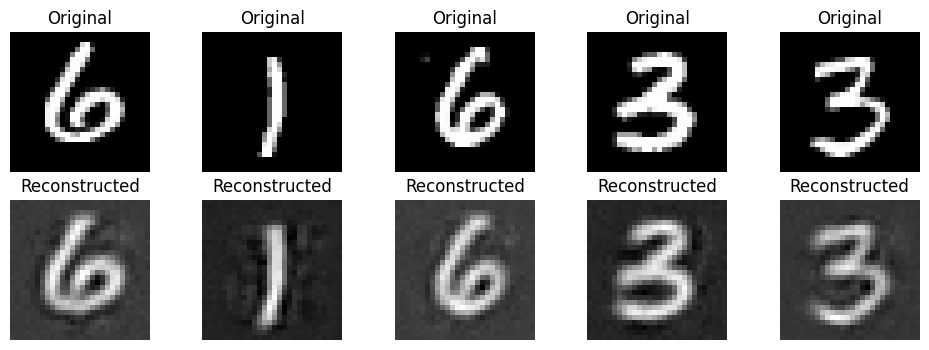

Epochs:  25%|██▌       | 1/4 [00:11<00:33, 11.06s/it]

Epoch [2/4],         Train Loss: 0.0898,         Val Loss: 0.0774
Checkpoint saved at checkpoints\autoencoder_best.pth


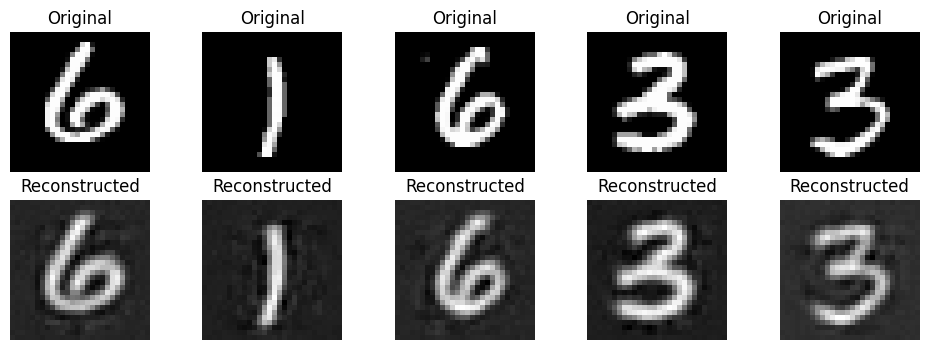

Epochs:  50%|█████     | 2/4 [00:21<00:21, 10.91s/it]

Epoch [3/4],         Train Loss: 0.0718,         Val Loss: 0.0693
Checkpoint saved at checkpoints\autoencoder_best.pth


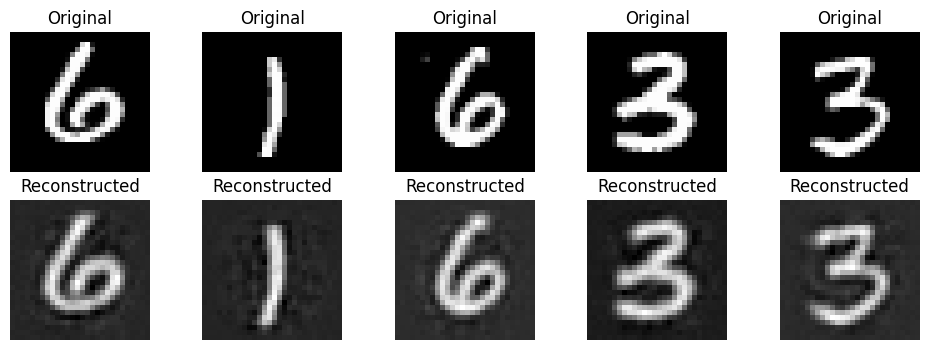

Epochs:  75%|███████▌  | 3/4 [00:32<00:10, 10.98s/it]

Epoch [4/4],         Train Loss: 0.0635,         Val Loss: 0.0603
Checkpoint saved at checkpoints\autoencoder_best.pth


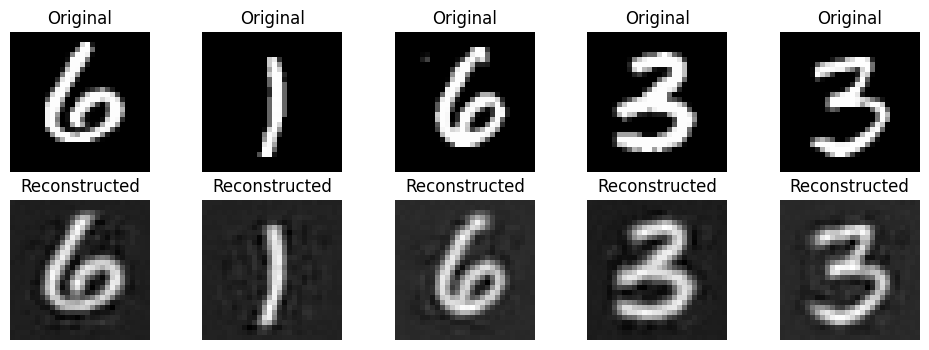

Epochs: 100%|██████████| 4/4 [00:43<00:00, 10.90s/it]


In [4]:

# Train Autoencoder
autoencoder = Autoencoder().to(device)
criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)

print("Training Autoencoder...")
for epoch in tqdm(range(num_epochs_ae), desc="Epochs"):
    autoencoder.train()
    train_loss = 0
    for images, _ in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device)
        
        # Forward pass
        outputs = autoencoder(images)
        loss = criterion_ae(outputs, images)
        
        # Backward pass
        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        
        train_loss += loss.item()
    
    # Validation
    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for images, _ in tqdm(val_loader, desc="Validation", leave=False):
            images = images.to(device)
            outputs = autoencoder(images)
            val_loss += criterion_ae(outputs, images).item()
    
    print(f'Epoch [{epoch+1}/{num_epochs_ae}], \
        Train Loss: {train_loss/len(train_loader):.4f}, \
        Val Loss: {val_loss/len(val_loader):.4f}')
    

    # Early stopping and checkpoint saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save the checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, 'autoencoder_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': autoencoder.state_dict(),
            'optimizer_state_dict': optimizer_ae.state_dict(),
            'val_loss': val_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break


    # Visualise
    with torch.no_grad():
        dataiter = iter(val_loader)
        images, _ = next(dataiter)
        images = images.to(device)
        outputs = autoencoder(images)
        images = images.cpu()
        outputs = outputs.cpu()
 
        fig, axes = plt.subplots(2, 5, figsize=(12, 4))
        for i in range(5):
            axes[0, i].imshow(images[i].view(28, 28), cmap='gray')
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')
            axes[1, i].imshow(outputs[i].view(28, 28), cmap='gray')
            axes[1, i].set_title('Reconstructed')
            axes[1, i].axis('off')
        plt.show()


In [5]:
print("Testing Autoencoder...")
autoencoder.eval()
test_loss = 0
with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = autoencoder(images)
        test_loss += criterion_ae(outputs, images).item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')

Testing Autoencoder...


Testing: 100%|██████████| 79/79 [00:01<00:00, 50.21it/s]

Test Loss: 0.0590


In [6]:

# Classifier Model
class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.fc1 = nn.Linear(latent_dim, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.encoder(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [7]:

# Initialize classifier with frozen encoder
classifier = Classifier(autoencoder.encoder).to(device)

# Freeze encoder parameters
for param in classifier.encoder.parameters():
    param.requires_grad = False

# Train Classifier
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(classifier.parameters(), lr=learning_rate)

print("\nTraining Classifier...")
for epoch in tqdm(range(num_epochs_cls), desc="Epochs"):
    classifier.train()
    train_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = classifier(images)
        loss = criterion_cls(outputs, labels)
        
        # Backward pass
        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    # Validation
    classifier.eval()
    val_loss_classifier = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = classifier(images)
            loss = criterion_cls(outputs, labels)
            val_loss_classifier += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss_classifier = val_loss_classifier / len(val_loader)
    train_loss_classifier = train_loss / len(train_loader)
    val_accuracy = 100. * val_correct / val_total
    # Early stopping and checkpoint saving
    if val_loss_classifier < best_val_loss_classifier:
        best_val_loss_classifier = val_loss_classifier
        patience_counter_classifier = 0
        # Save the checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, 'classifier_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': classifier.state_dict(),
            'optimizer_state_dict': optimizer_cls.state_dict(),
            'val_loss': val_loss_classifier,
        }, checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")
    else:
        patience_counter_classifier += 1
        if patience_counter_classifier >= patience_classifier:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    print(f'Epoch [{epoch+1}/{num_epochs_cls}], \
        Train Loss: {train_loss_classifier:.4f}, \
        Val Loss: {val_loss_classifier:.4f}, \
        Val Accuracy: {val_accuracy:.2f}%')



Training Classifier...


Epochs:  25%|██▌       | 1/4 [00:10<00:30, 10.25s/it]

Checkpoint saved at checkpoints\classifier_best.pth
Epoch [1/4],         Train Loss: 0.5491,         Val Loss: 0.3020,         Val Accuracy: 91.37%


Epochs:  50%|█████     | 2/4 [00:20<00:20, 10.20s/it]

Checkpoint saved at checkpoints\classifier_best.pth
Epoch [2/4],         Train Loss: 0.2629,         Val Loss: 0.2350,         Val Accuracy: 93.52%


Epochs:  75%|███████▌  | 3/4 [00:30<00:10, 10.07s/it]

Checkpoint saved at checkpoints\classifier_best.pth
Epoch [3/4],         Train Loss: 0.2046,         Val Loss: 0.1872,         Val Accuracy: 94.76%


Epochs: 100%|██████████| 4/4 [00:40<00:00, 10.05s/it]

Checkpoint saved at checkpoints\classifier_best.pth
Epoch [4/4],         Train Loss: 0.1668,         Val Loss: 0.1646,         Val Accuracy: 95.25%


In [8]:

# Test the classifier
classifier.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f'\nFinal Test Accuracy: {100.*test_correct/test_total:.2f}%')


Final Test Accuracy: 95.28%


In [17]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)
print(device)
plot_tsne(autoencoder.encoder, test_loader, device)

cuda
